## Part A: Data Preprocessing Pipeline

This section describes the data preprocessing steps applied to the dataset,
including data cleaning, data transformation, and data reduction.

## 1. Data Cleaning

In [1]:
import pandas as pd

In [57]:
df=pd.read_csv('../achieve/train_genetic_disorders.csv')

In [58]:
total_rows = len(df)
missing_counts = total_rows - df.count()
df

,Patient Id,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Patient First Name,Family Name,Father's name,...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,PID0x6418,2.0,Yes,No,Yes,No,4.760603,Richard,NaN,Larre,...,NaN,9.857562,NaN,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,PID0x25d5,4.0,Yes,Yes,No,No,4.910669,Mike,NaN,Brycen,...,Multiple,5.522560,normal,1.0,NaN,1.0,1.0,0.0,NaN,Cystic fibrosis
2,PID0x4a82,6.0,Yes,No,No,No,4.893297,Kimberly,NaN,Nashon,...,Singular,NaN,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,PID0x4ac8,12.0,Yes,No,Yes,No,4.705280,Jeffery,Hoelscher,Aayaan,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,PID0x1bf7,11.0,Yes,No,NaN,Yes,4.720703,Johanna,Stutzman,Suave,...,Multiple,4.098210,NaN,0.0,0.0,0.0,0.0,NaN,Multifactorial genetic inheritance disorders,Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22079,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22080,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22081,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## The first step of cleaning: Delete all blank lines.

In [59]:
df = df.dropna(how='all')
df = df.drop(columns = ['Patient Id','Patient First Name',"Father's name",'Location of Institute'])
print(df.shape)

(21011, 41)


## Find all the missing values

In [60]:
missing_count = df.isnull().sum()
missing_percent = df.isnull().sum() / len(df) * 100
missing_summary = pd.concat([missing_count, missing_percent], axis=1)
missing_summary.columns = ['missing_count', 'missing_percent']
missing_summary.sort_values(by='missing_percent', ascending=False)

,missing_count,missing_percent
Family Name,9240,43.976964
Mother's age,5718,27.214316
Father's age,5689,27.076293
Institute Name,4860,23.130741
Autopsy shows birth defect (if applicable),4164,19.818190
Maternal gene,2694,12.821855
Symptom 2,2112,10.051878
H/O substance abuse,2090,9.947171
Test 5,2072,9.861501
Follow-up,2070,9.851982


 ## Since Family Name missing value >30%,didn't caused any effect towards genetic disorder. Drop might be the most safety way to reduce noise.

In [61]:
df = df.drop(columns=['Family Name'])

 ## Missing value between 20% - 30 % , check the importance of the data

In [62]:
df = df.drop(columns=['Institute Name'])

## Missing rate < 20% , Fill in the data

In [63]:
from sklearn.impute import SimpleImputer
cat_cols = df.select_dtypes(include=['object']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])


In [64]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])
df[num_cols].isnull().sum().sort_values(ascending=False).head()

Patient Age               0
Blood cell count (mcL)    0
Mother's age              0
Father's age              0
Test 1                    0
dtype: int64

## Check Duplicated

In [65]:
df.duplicated().sum()

np.int64(0)

## Check the data

In [66]:
df[num_cols].describe()

,Patient Age,Blood cell count (mcL),Mother's age,Father's age,Test 1,Test 2,Test 3,Test 4,Test 5,No. of previous abortion,White Blood cell count (thousand per microliter),Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5
count,21011.000000,21011.000000,21011.000000,21011.000000,21011.0,21011.0,21011.0,21011.0,21011.0,21011.000000,21011.000000,21011.000000,21011.000000,21011.000000,21011.000000,21011.000000
mean,6.976489,4.899004,34.652468,41.958022,0.0,0.0,0.0,1.0,0.0,2.000095,7.483550,0.631955,0.597830,0.581505,0.449479,0.415735
std,4.179495,0.199829,8.403752,11.124985,0.0,0.0,0.0,0.0,0.0,1.340718,2.521118,0.482285,0.490348,0.493324,0.497453,0.492860
min,0.000000,4.092727,18.000000,20.000000,0.0,0.0,0.0,1.0,0.0,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,4.763230,29.000000,35.000000,0.0,0.0,0.0,1.0,0.0,1.000000,5.655274,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.000000,4.899548,35.000000,42.000000,0.0,0.0,0.0,1.0,0.0,2.000000,7.473071,1.000000,1.000000,1.000000,0.000000,0.000000
75%,10.000000,5.033977,40.000000,49.000000,0.0,0.0,0.0,1.0,0.0,3.000000,9.276613,1.000000,1.000000,1.000000,1.000000,1.000000
max,14.000000,5.609829,51.000000,64.000000,0.0,0.0,0.0,1.0,0.0,4.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2. Data Transformation

In [67]:
low_variance_cols = df.columns[df.nunique() <= 1]
df = df.drop(columns=low_variance_cols)

In [68]:
cat_cols = df.select_dtypes(include=['object']).columns

In [69]:
binary_cols = []

for col in cat_cols:
    if df[col].nunique() == 2:
        binary_cols.append(col)

binary_cols
df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})
df

C:\Users\User\AppData\Local\Temp\ipykernel_31832\3139900041.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({'Yes':1, 'No':0})


,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,Respiratory Rate (breaths/min),...,Birth defects,White Blood cell count (thousand per microliter),Blood test result,Symptom 1,Symptom 2,Symptom 3,Symptom 4,Symptom 5,Genetic Disorder,Disorder Subclass
0,2.0,1,0,1,0,4.760603,35.0,42.0,Alive,Normal (30-60),...,Singular,9.857562,slightly abnormal,1.0,1.0,1.0,1.0,1.0,Mitochondrial genetic inheritance disorders,Leber's hereditary optic neuropathy
1,4.0,1,1,0,0,4.910669,35.0,23.0,Deceased,Tachypnea,...,Multiple,5.522560,normal,1.0,1.0,1.0,1.0,0.0,Mitochondrial genetic inheritance disorders,Cystic fibrosis
2,6.0,1,0,0,0,4.893297,41.0,22.0,Alive,Normal (30-60),...,Singular,7.473071,normal,0.0,1.0,1.0,1.0,1.0,Multifactorial genetic inheritance disorders,Diabetes
3,12.0,1,0,1,0,4.705280,21.0,42.0,Deceased,Tachypnea,...,Singular,7.919321,inconclusive,0.0,0.0,1.0,0.0,0.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
4,11.0,1,0,1,1,4.720703,32.0,42.0,Alive,Tachypnea,...,Multiple,4.098210,slightly abnormal,0.0,0.0,0.0,0.0,0.0,Multifactorial genetic inheritance disorders,Cancer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21006,11.0,0,1,1,0,5.090495,46.0,42.0,Alive,Normal (30-60),...,Multiple,7.473071,normal,1.0,1.0,0.0,0.0,0.0,Single-gene inheritance diseases,Tay-Sachs
21007,7.0,0,0,0,1,5.214750,35.0,38.0,Alive,Tachypnea,...,Singular,7.086312,slightly abnormal,1.0,1.0,1.0,0.0,1.0,Mitochondrial genetic inheritance disorders,Leigh syndrome
21008,5.0,1,0,1,1,5.084831,28.0,28.0,Alive,Normal (30-60),...,Multiple,7.924746,slightly abnormal,1.0,0.0,0.0,1.0,1.0,Multifactorial genetic inheritance disorders,Leigh syndrome
21009,1.0,1,0,0,1,5.224828,33.0,24.0,Deceased,Tachypnea,...,Multiple,12.000000,inconclusive,0.0,1.0,1.0,1.0,0.0,Mitochondrial genetic inheritance disorders,Mitochondrial myopathy


In [70]:
df = pd.get_dummies(df,columns = ['Blood test result','Disorder Subclass','Gender','Birth asphyxia','Autopsy shows birth defect (if applicable)','H/O radiation exposure (x-ray)','H/O substance abuse',])
df

,Patient Age,Genes in mother's side,Inherited from father,Maternal gene,Paternal gene,Blood cell count (mcL),Mother's age,Father's age,Status,Respiratory Rate (breaths/min),...,Autopsy shows birth defect (if applicable)_Not applicable,Autopsy shows birth defect (if applicable)_Yes,H/O radiation exposure (x-ray)_-,H/O radiation exposure (x-ray)_No,H/O radiation exposure (x-ray)_Not applicable,H/O radiation exposure (x-ray)_Yes,H/O substance abuse_-,H/O substance abuse_No,H/O substance abuse_Not applicable,H/O substance abuse_Yes
0,2.0,1,0,1,0,4.760603,35.0,42.0,Alive,Normal (30-60),...,True,False,False,True,False,False,False,True,False,False
1,4.0,1,1,0,0,4.910669,35.0,23.0,Deceased,Tachypnea,...,True,False,False,False,True,False,False,False,True,False
2,6.0,1,0,0,0,4.893297,41.0,22.0,Alive,Normal (30-60),...,True,False,False,False,False,True,True,False,False,False
3,12.0,1,0,1,0,4.705280,21.0,42.0,Deceased,Tachypnea,...,False,False,True,False,False,False,False,False,True,False
4,11.0,1,0,1,1,4.720703,32.0,42.0,Alive,Tachypnea,...,True,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21006,11.0,0,1,1,0,5.090495,46.0,42.0,Alive,Normal (30-60),...,True,False,False,True,False,False,False,False,True,False
21007,7.0,0,0,0,1,5.214750,35.0,38.0,Alive,Tachypnea,...,True,False,False,False,True,False,False,True,False,False
21008,5.0,1,0,1,1,5.084831,28.0,28.0,Alive,Normal (30-60),...,True,False,False,True,False,False,False,False,True,False
21009,1.0,1,0,0,1,5.224828,33.0,24.0,Deceased,Tachypnea,...,True,False,False,True,False,False,True,False,False,False


## 3. Feature Scaling by using Standardzation

In [71]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

## Extra： Data Validation

In [72]:
# ========== Data Validation After Feature Scaling ==========
import numpy as np

# 1. Re-select numeric columns in the current df (avoid issues from column name changes)
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(f"Current numeric columns to validate:\n{num_cols.tolist()}\n")

# 2. Validation 1: No missing values (required for PCA/model training)
missing_check = df[num_cols].isnull().sum()
print("Missing value check for numeric columns (should be 0):")
print(missing_check)
if missing_check.sum() == 0:
    print("✅ Missing value validation passed: All numeric columns have no missing values\n")
else:
    print("❌ Missing value validation failed: Unhandled NaN values exist\n")

# 3. Validation 2: Mean ≈ 0 and variance ≈ 1 after standard scaling (core validation)
# Calculate mean and variance for each column (rounded to 4 decimal places)
scaling_check = pd.DataFrame({
    'Mean': df[num_cols].mean().round(4),
    'Variance': df[num_cols].var().round(4)
})
print("Mean/variance validation after feature scaling (Mean ≈ 0, Variance ≈ 1):")
print(scaling_check)

# Batch check if scaling meets requirements (|Mean| < 0.01, 0.9 < Variance < 1.1)
mean_pass = np.all(np.abs(scaling_check['Mean']) < 0.01)
var_pass = np.all((scaling_check['Variance'] > 0.9) & (scaling_check['Variance'] < 1.1))

if mean_pass and var_pass:
    print("✅ Feature scaling validation passed: Mean ≈ 0, Variance ≈ 1\n")
else:
    print("⚠️ Feature scaling not fully compliant: Mean/variance of some columns deviate from standard values\n")

# 4. Optional: Validate data types (ensure numeric, no string混入)
dtype_check = df[num_cols].dtypes
print("Data type validation for numeric columns (should be int64/float64):")
print(dtype_check)
if all([dtype in ['int64', 'float64'] for dtype in dtype_check]):
    print("✅ Data type validation passed\n")
else:
    print("❌ Data type validation failed: Non-numeric columns exist\n")

# 5. Optional: Preview first 5 rows of scaled data (visual check)
print("Preview of first 5 rows of scaled data:")
print(df[num_cols].head())

Current numeric columns to validate:
['Patient Age', "Genes in mother's side", 'Inherited from father', 'Maternal gene', 'Paternal gene', 'Blood cell count (mcL)', "Mother's age", "Father's age", 'Folic acid details (peri-conceptional)', 'H/O serious maternal illness', 'Assisted conception IVF/ART', 'History of anomalies in previous pregnancies', 'No. of previous abortion', 'White Blood cell count (thousand per microliter)', 'Symptom 1', 'Symptom 2', 'Symptom 3', 'Symptom 4', 'Symptom 5']

Missing value check for numeric columns (should be 0):
Patient Age                                         0
Genes in mother's side                              0
Inherited from father                               0
Maternal gene                                       0
Paternal gene                                       0
Blood cell count (mcL)                              0
Mother's age                                        0
Father's age                                        0
Folic acid details

In [73]:
df.head().T

,0,1,2,3,4
Patient Age,-1.19072,-0.712182,-0.233643,1.201971,0.962702
Genes in mother's side,0.824421,0.824421,0.824421,0.824421,0.824421
Inherited from father,-0.801328,1.247929,-0.801328,-0.801328,-0.801328
Maternal gene,0.799407,-1.250927,-1.250927,0.799407,0.799407
Paternal gene,-0.876106,-0.876106,-0.876106,-0.876106,1.141415
Blood cell count (mcL),-0.692616,0.058375,-0.02856,-0.969473,-0.892293
Mother's age,0.041355,0.041355,0.755339,-1.624607,-0.315636
Father's age,0.003773,-1.704135,-1.794025,0.003773,0.003773
Status,Alive,Deceased,Alive,Deceased,Alive
Respiratory Rate (breaths/min),Normal (30-60),Tachypnea,Normal (30-60),Tachypnea,Tachypnea


In [74]:
# import models
from sklearn.model_selection import train_test_split as split, KFold, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
import matplotlib.pyplot as plt

In [75]:
categorical_cols =df.select_dtypes(include=["object"]).columns
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [76]:
df.head().T

,0,1,2,3,4
Patient Age,-1.19072,-0.712182,-0.233643,1.201971,0.962702
Genes in mother's side,0.824421,0.824421,0.824421,0.824421,0.824421
Inherited from father,-0.801328,1.247929,-0.801328,-0.801328,-0.801328
Maternal gene,0.799407,-1.250927,-1.250927,0.799407,0.799407
Paternal gene,-0.876106,-0.876106,-0.876106,-0.876106,1.141415
Blood cell count (mcL),-0.692616,0.058375,-0.02856,-0.969473,-0.892293
Mother's age,0.041355,0.041355,0.755339,-1.624607,-0.315636
Father's age,0.003773,-1.704135,-1.794025,0.003773,0.003773
Status,0,1,0,1,0
Respiratory Rate (breaths/min),0,1,0,1,1


In [77]:
#split features and target
X = df.drop(columns = ['Genetic Disorder'])
y = df['Genetic Disorder']

In [78]:
#split data into train and test set
X_train, X_test, y_train, y_test = split(X,y,test_size = 0.25,random_state = 42)

In [79]:
dtc = DecisionTreeClassifier().fit(X_train,y_train)
print(f'Decision Tree Classifier Performance:{dtc.score(X_test,y_test):.3%}')

Decision Tree Classifier Performance:84.238%


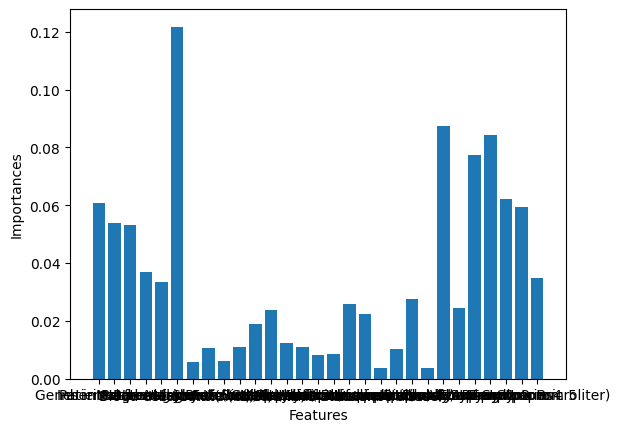

In [142]:
#DecisionTreeClassifier Optimization
dtc = DecisionTreeClassifier(max_depth =10, random_state = 42).fit(X,y)

features_importances = dtc.feature_importances_
plt.bar(X.columns, features_importances)
plt.xlabel('Features')
plt.ylabel('Importances')
plt.show()

In [150]:
#Model cross validation score without optimizing
kf = KFold(n_splits=6, shuffle=True, random_state=42)

models = {}
models['knn'] = KNeighborsClassifier(n_neighbors = 117, weights ="distance")
models['lgr'] = LogisticRegression(random_state = 42)
models['dtc'] = DecisionTreeClassifier(max_depth =5, random_state = 42)
models['rfc'] = RandomForestClassifier(n_estimators = 70,max_features = 5, max_depth =11,random_state = 42)
models['gbc'] = GradientBoostingClassifier(learning_rate = 0.1,n_estimators = 80, max_features = 3, max_depth = 5,random_state = 42)
models['mlp'] = MLPClassifier(max_iter = 164,activation = "relu",hidden_layer_sizes = (5,5,5),random_state = 42)
models['svc'] = SVC(kernel = "rbf", C =1.2, gamma = 0.2,random_state = 42)

for n in models:
    scores = cross_val_score(models[n], X_test, y_test, cv=kf, n_jobs=1)
    print(f'{n}: {scores.mean():.3%} +/- {scores.std():.3%}')

knn: 57.015% +/- 1.650%
lgr: 57.167% +/- 1.452%
dtc: 59.813% +/- 2.101%
rfc: 57.547% +/- 1.576%
gbc: 58.138% +/- 1.581%


C:\Users\User\ML_Ass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\ML_Ass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\ML_Ass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\ML_Ass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (164) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\User\ML_Ass\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:

mlp: 57.795% +/- 1.884%
svc: 56.786% +/- 1.803%
